# Simulating and visualizing a system of particles with interactions between pairs and triplets

## Documentation for Particle Simulation Code

This Python code simulates the movement of particles and their interactions within a 2D space using Pygame for visualization. It incorporates both **pairwise** and **triplet interactions** among particles and handles different boundary conditions (either **hard boundaries** or **periodic boundaries**). Additionally, the code records particle positions at specified time intervals and stores the data in a CSV file. Below is an explanation of the main components of the code:

---

### **Simulation Parameters**

- **boundary**: Defines the boundary condition of the simulation. The possible values are:
  - `"Hard"`: Particles reflect off the edges of the screen.
  - `"Periodic"`: Particles wrap around to the opposite side when they exit one side of the screen.
- **num_particles**: The number of particles in the simulation.
- **width, height**: The dimensions of the simulation area.
- **interaction_distance**: The distance at which pairwise interactions occur between particles.
- **triplet_interaction_distance**: The distance at which triplet interactions occur.
- **speed**: The speed at which particles move.
- **dt**: The time step for the simulation.
- **simulation_duration**: The total simulation time in arbitrary time units.
- **time_step_record**: The frequency with which particle positions are recorded (in simulation time).

---

### **Particle Class**

The `Particle` class represents each particle in the simulation and contains the following attributes and methods:

- **Attributes**:
  - `position`: A 2D numpy array holding the particle’s position (x, y).
  - `velocity`: A 2D numpy array representing the particle’s velocity.
  - `move_time`: Random time during which the particle moves before resting.
  - `rest_time`: Random time the particle rests.
  - `timer`: Tracks the remaining time the particle will continue its current state (moving or resting).
  - `moving`: A boolean flag indicating whether the particle is moving or resting.

- **Methods**:
  - `update()`: This method updates the position of the particle based on its velocity and handles both movement and resting states. It also ensures particles stay within the boundaries defined by the simulation (either through hard boundaries or periodic boundaries).

---

### **Interaction Functions**

1. **pairwise_interact(particles)**:
   - This function computes the interaction forces between pairs of particles. If two particles are within the `interaction_distance`, they interact. The force is proportional to the distance between them and inversely affects their velocities.

2. **triplet_interact(particles)**:
   - This function computes the interaction forces among triplets of particles. It checks if all three particles in a triplet are within the `triplet_interaction_distance`. If so, the particles interact by moving away from their centroid, with the interaction strength defined by `triplet_interaction_strength`.

---

### **Simulation Loop**

- **Main loop**: 
   - The simulation runs for `simulation_duration` time steps. In each step:
     - Particle positions are updated based on their velocities.
     - Pairwise and triplet interactions are handled.
     - Particle positions are recorded at intervals specified by `time_step_record`.
     - The screen is updated with the new particle positions and interactions.

- **Recording Positions**: 
   - At each time step, the positions of the particles are recorded in a `pandas` DataFrame. This is then saved to a CSV file, `particle_positions.csv`.

---

### **Output**

The simulation will output a CSV file that contains the positions and velocities of all particles over time. The columns in the CSV file are as follows:

- **time**: The current time step.
- **x1, y1, x2, y2, ..., xn, yn**: The x and y coordinates for each particle at that time step (where `n` is the number of particles).
- **vx1, vy1, vx2, vy2, ..., vxn, vyn**: The x and y velocities for each particle at that time step (where `n` is the number of particles).

## The code

In [15]:
import random
# import pygame  # type: ignore
import numpy as np  # type: ignore
import pandas as pd  # type: ignore
from hoi.metrics import Oinfo, Sinfo  # type: ignore

# Simulation parameters
boundary = "Hard"  # "Periodic", "Hard"
num_particles = 3
width, height = 240, 135  # 1920, 1080
interaction_distance = 25
triplet_interaction_distance = 100  # Distance for triplet interactions
speed = 15
dt = 0.1

# Total simulation time in units
simulation_duration = 1000 # 3603

# Time step for recording positions
time_step_record = 3

# Strength for interactions
pairwise_interaction_strength = np.linspace(-0.5, 0.5, 21)  # Repulsive if >0, attractive if <0
triplet_interaction_strength = np.linspace(-0.2, 0.2, 21)  # Strength for triplet interactions

# Resting and moving times
move_time_min = 1
move_time_max = 4
rest_time_min = 5
rest_time_max = 5

# Initialize Pygame
# pygame.init()
# screen = pygame.display.set_mode((width, height))
# clock = pygame.time.Clock()


if boundary == "Hard":
    # Particle class with hard boundary conditions
    class Particle:
        def __init__(self):
            self.position = np.array([random.uniform(0, width), random.uniform(0, height)])
            self.velocity = np.zeros(2)
            self.move_time = random.uniform(move_time_min, move_time_max)
            self.rest_time = random.uniform(rest_time_min, rest_time_max)
            self.timer = self.move_time
            self.moving = True
    
        def update(self):
            if self.moving:
                self.position += self.velocity * dt
                self.timer -= dt
    
                # Reverse velocity and keep position within boundaries when hitting walls
                for dim in range(2):  # Check both x (dim=0) and y (dim=1) dimensions
                    if self.position[dim] <= 0:
                        self.position[dim] = 0
                        self.velocity[dim] *= -1  # Reverse direction
                    elif self.position[dim] >= [width, height][dim]:
                        self.position[dim] = [width, height][dim]
                        self.velocity[dim] *= -1  # Reverse direction
    
                if self.timer <= 0:
                    self.timer = self.rest_time
                    self.moving = False
                    self.velocity = np.zeros(2)
            else:
                self.timer -= dt
                if self.timer <= 0:
                    self.timer = self.move_time
                    self.moving = True
                    angle = random.uniform(0, 2 * np.pi)
                    self.velocity = np.array([np.cos(angle), np.sin(angle)]) * speed

if boundary == "Periodic":
    # Particle class with periodic boundary conditions
    class Particle:
        def __init__(self):
            self.position = np.array([random.uniform(0, width), random.uniform(0, height)])
            self.velocity = np.zeros(2)
            self.move_time = random.uniform(move_time_min, move_time_max)
            self.rest_time = random.uniform(rest_time_min, rest_time_max)
            self.timer = self.move_time
            self.moving = True
    
        def update(self):
            if self.moving:
                self.position += self.velocity * dt
                self.timer -= dt
                if self.timer <= 0:
                    self.timer = self.rest_time
                    self.moving = False
                    self.velocity = np.zeros(2)
            else:
                self.timer -= dt
                if self.timer <= 0:
                    self.timer = self.move_time
                    self.moving = True
                    angle = random.uniform(0, 2 * np.pi)
                    self.velocity = np.array([np.cos(angle), np.sin(angle)]) * speed
    
            # Ensure particles wrap around the screen (toroidal space)
            self.position = np.mod(self.position, [width, height])

# Pairwise interaction function (repulsive/attractive)
def pairwise_interact(particles, pairwise_interaction_strength):
    for i in range(len(particles)):
        for j in range(i+1, len(particles)):
            p1, p2 = particles[i], particles[j]
            distance = np.linalg.norm(p1.position - p2.position)
            if distance < interaction_distance:
                # Apply pairwise interaction force
                direction = (p1.position - p2.position) / distance
                force = pairwise_interaction_strength * (interaction_distance - distance)
                p1.velocity += direction * force
                p2.velocity -= direction * force

# Triplet interaction function
def triplet_interact(particles, triplet_interaction_strength):
    for i in range(len(particles)):
        for j in range(i+1, len(particles)):
            for k in range(j+1, len(particles)):
                p1, p2, p3 = particles[i], particles[j], particles[k]
                d12 = np.linalg.norm(p1.position - p2.position)
                d13 = np.linalg.norm(p1.position - p3.position)
                d23 = np.linalg.norm(p2.position - p3.position)

                # Check if all three particles are within triplet interaction distance
                if d12 < triplet_interaction_distance and d13 < triplet_interaction_distance and d23 < triplet_interaction_distance:
                    # Compute the interaction force for the triplet
                    centroid = (p1.position + p2.position + p3.position) / 3
                    for p in [p1, p2, p3]:
                        direction = (p.position - centroid)
                        force = -triplet_interaction_strength * np.linalg.norm(direction)
                        p.velocity -= direction * force / np.linalg.norm(direction)  # Move away from the centroid

results = []
for pair_s in pairwise_interaction_strength:
    for triplet_s in triplet_interaction_strength:

        # Initialize particles
        particles = [Particle() for _ in range(num_particles)]

        # DataFrame to store particle positions
        columns = (
            ["time", "F2", "F3"]
            + [f"{r}{i+1}" for i in range(num_particles) for r in ("x", "y")]
            + [f"{v}{i+1}" for i in range(num_particles) for v in ("vx", "vy")]
        )
        data = []
        current_time = 0.0
        next_record_time = 0.0

        # Main simulation loop
        running = True
        while running and current_time <= simulation_duration:
            # for event in pygame.event.get():
            #     if event.type == pygame.QUIT:
            #        running = False

            # Update particle positions and states
            for particle in particles:
                particle.update()

            # Handle pairwise and triplet interactions
            pairwise_interact(particles, pair_s)
            if len(particles) > 2:
                triplet_interact(particles, triplet_s)

            # Record positions at specified intervals
            if current_time >= next_record_time:
                row = [current_time, pair_s, triplet_s]
                for particle in particles:
                    row.extend(particle.position)
                    row.extend(particle.velocity)
                data.append(row)
                next_record_time += time_step_record

            # Clear screen
            # screen.fill((0, 0, 0))

            # if boundary == "Hard":
            #     pygame.draw.rect(screen, (255, 255, 255), (0, 0, width, height), 2)  # Draw boundary

            # Draw particles
            # for particle in particles:
            #     pygame.draw.circle(screen, (255, 0, 0), particle.position.astype(int), 5)


            # pygame.display.flip()
            # clock.tick(60)
            current_time += dt

        # pygame.quit()

        # Create and save the DataFrame
        df = pd.DataFrame(data, columns=columns)

        # Estimate O-information
        if num_particles == 3:
            x1 = df["x1"].values
            x2 = df["x2"].values
            x3 = df["x3"].values
            y1 = df["y1"].values
            y2 = df["y2"].values
            y3 = df["y3"].values
            # o1 = df[df["permuted_id"] == 0]["corrected_orientation"].values

            # Estimate distances time series
            d1 = np.power(np.power(x1, 2) + np.power(y1, 2), 1 / 2)
            d2 = np.power(np.power(x2, 2) + np.power(y2, 2), 1 / 2)
            d3 = np.power(np.power(x3, 2) + np.power(y3, 2), 1 / 2)

            # Generate data for estimate O-information of triplet interaction
            data_1 = np.column_stack((d1, d2, d3))

            # Define O-information model from HoI library classes
            model_1 = Oinfo(data_1, verbose=0)
            # model_2 = Oinfo(data_2, verbose=0)
            model_3 = Sinfo(data_1, verbose=0)
            # model_4 = Sinfo(data_2, verbose=0)

            # Compute HoI metric using the Gaussian Copula entropy
            hoi_value_1 = model_1.fit(minsize=3, maxsize=3, method="gc")
            # hoi_value_2 = model_2.fit(minsize=3, maxsize=3, method="gc")
            hoi_value_3 = model_3.fit(minsize=3, maxsize=3, method="gc")
            # hoi_value_4 = model_4.fit(minsize=3, maxsize=3, method="gc")

            df["oinfo_distance"] = hoi_value_1[0][0]
            df["sinfo_distance"] = hoi_value_3[0][0]

        results.append(df)

        print("Finish process with F2={}, F3={}".format(pair_s, triplet_s))

results = pd.concat(results, ignore_index=True)
results

Finish process with F2=-0.5, F3=-0.2
Finish process with F2=-0.5, F3=-0.18000000000000002
Finish process with F2=-0.5, F3=-0.16
Finish process with F2=-0.5, F3=-0.14
Finish process with F2=-0.5, F3=-0.12000000000000001
Finish process with F2=-0.5, F3=-0.1
Finish process with F2=-0.5, F3=-0.08000000000000002
Finish process with F2=-0.5, F3=-0.06
Finish process with F2=-0.5, F3=-0.04000000000000001
Finish process with F2=-0.5, F3=-0.020000000000000018
Finish process with F2=-0.5, F3=0.0
Finish process with F2=-0.5, F3=0.01999999999999999
Finish process with F2=-0.5, F3=0.03999999999999998
Finish process with F2=-0.5, F3=0.06
Finish process with F2=-0.5, F3=0.08000000000000002
Finish process with F2=-0.5, F3=0.09999999999999998
Finish process with F2=-0.5, F3=0.12
Finish process with F2=-0.5, F3=0.14
Finish process with F2=-0.5, F3=0.15999999999999998
Finish process with F2=-0.5, F3=0.18
Finish process with F2=-0.5, F3=0.2
Finish process with F2=-0.45, F3=-0.2
Finish process with F2=-0.45

,time,F2,F3,x1,y1,x2,y2,x3,y3,vx1,vy1,vx2,vy2,vx3,vy3,oinfo_distance,sinfo_distance
0,0.0,-0.5,-0.2,192.247648,39.143151,-12.214011,5.937237,187.825671,40.491185,7.640296,1.475127,179.872966,55.520055,4.573715,-7.412364,0.000850,3.534237
1,3.0,-0.5,-0.2,177.483023,57.789170,-0.249160,-6.412110,180.634336,50.736824,37.264371,-40.146118,160.752339,65.955934,-22.010773,15.868644,0.000850,3.534237
2,6.1,-0.5,-0.2,177.483023,57.789170,65.024293,-235.892470,180.634336,50.736824,-133.166369,261.838941,153.973033,71.824184,76.929317,-53.854307,0.000850,3.534237
3,9.1,-0.5,-0.2,157.606743,70.987178,-49.026899,-1.251155,168.290550,63.261422,-30.384316,20.857383,154.190328,70.367600,18.044314,-15.150101,0.000850,3.534237
4,12.1,-0.5,-0.2,166.732545,67.756422,-78.817709,-83.876223,165.252118,65.347160,51.387795,92.090833,166.077411,52.311469,20.751358,-7.226020,0.000850,3.534237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147289,987.0,0.5,0.2,118.825240,0.675988,0.000000,0.000000,168.978958,130.297138,2.117949,14.849724,32.831372,6.913531,0.000000,0.000000,0.000841,0.059381
147290,990.0,0.5,0.2,118.825240,0.675988,0.000000,0.000000,172.791267,114.210387,0.000000,0.000000,32.831372,6.913531,0.000000,0.000000,0.000841,0.059381
147291,993.0,0.5,0.2,126.165557,17.111308,6.116931,13.696100,172.791267,114.210387,0.000000,0.000000,30.012360,26.208691,-2.168471,14.842430,0.000841,0.059381
147292,996.0,0.5,0.2,143.292963,55.460389,0.000000,0.000000,158.447196,89.583214,0.000000,0.000000,25.024877,60.346280,0.000000,0.000000,0.000841,0.059381


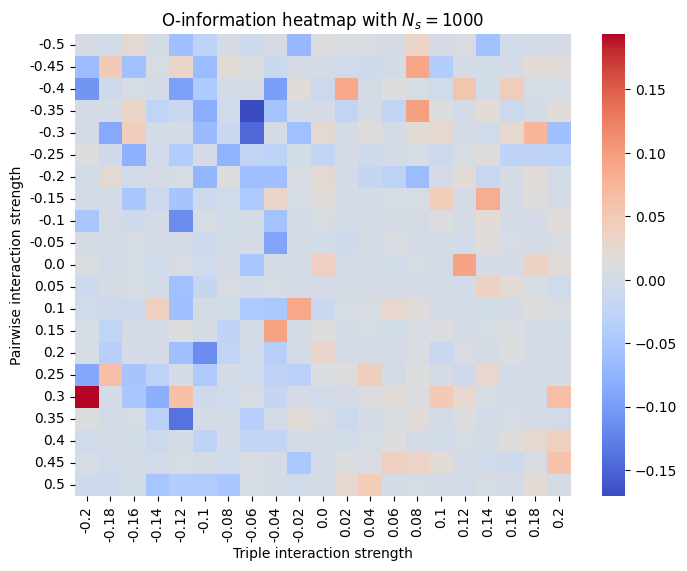

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot for heatmap
results_df = results[["F2", "F3", "oinfo_distance"]].drop_duplicates()
results_df["F2"] = results_df["F2"].round(3)
results_df["F3"] = results_df["F3"].round(3)
pivot = results_df.pivot(index="F2", columns="F3", values="oinfo_distance")

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap="coolwarm", annot=False, fmt=".2f")
plt.xlabel("Triple interaction strength")
plt.ylabel("Pairwise interaction strength")
plt.title("O-information heatmap with $N_s={}$".format(simulation_duration))
plt.show()

# plt.imshow(
#     pivot.values,
#     origin="lower",
#     cmap="coolwarm",
#     interpolation="bicubic",  # gives smooth appearance
#     extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()]
# )
# plt.colorbar(label="O-information")
# plt.xlabel("Triple interaction strength")
# plt.ylabel("Pairwise interaction strength")
# plt.title("O-information heatmap (smooth)")
# plt.show()

In [2]:
# Arrange final dataframe
video = str(num_particles) + "n_" + str(num_particles) + "m_0f_simulation"
time = np.tile(np.arange(0, simulation_duration, time_step_record), num_particles)
ids = np.repeat(np.arange(num_particles), int(simulation_duration / time_step_record))
position_x, position_y  = np.array([]), np.array([])
velocity_x, velocity_y  = np.array([]), np.array([])
for col in df.columns:
    vals = df[col].values
    if col[0] == "x":
        position_x = np.concatenate((position_x, vals), axis=None)
    elif col[0] == "y":
        position_y = np.concatenate((position_y, vals), axis=None)
    elif col[0:2] == "vx":
        velocity_x = np.concatenate((velocity_x, vals), axis=None)
    elif col[0:2] == "vy":
        velocity_y = np.concatenate((velocity_y, vals), axis=None)
    else:
        continue

df_final = pd.DataFrame({
    "particles": np.repeat(num_particles, len(time)),
    "video": [video]*len(time),
    "time": time,
    "permuted_id": ids,
    "position_x": position_x,
    "position_y": position_y,
    "corrected_orientation": np.arctan2(velocity_y, velocity_x)
})

df_final.to_csv("../output_files/df_" + str(num_particles) + "n.csv", index=False)
df_final


,particles,video,time,permuted_id,position_x,position_y,corrected_orientation
0,4,4n_4m_0f_simulation,0,0,195.655231,114.215701,0.536084
1,4,4n_4m_0f_simulation,3,0,201.353522,127.292457,0.642855
2,4,4n_4m_0f_simulation,6,0,201.353522,127.292457,0.682949
3,4,4n_4m_0f_simulation,9,0,225.344310,126.627556,0.660938
4,4,4n_4m_0f_simulation,12,0,238.839128,126.253549,0.407444
...,...,...,...,...,...,...,...
4799,4,4n_4m_0f_simulation,3588,3,3.063519,1.831905,-2.943539
4800,4,4n_4m_0f_simulation,3591,3,13.142552,7.868005,0.600600
4801,4,4n_4m_0f_simulation,3594,3,-4.816526,-6.838236,2.950487
4802,4,4n_4m_0f_simulation,3597,3,7.081626,2.265047,1.471705
